In [26]:
from __future__ import annotations

from typing import Annotated, TypedDict,List , operator , Literal

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq

from langchain_core.messages import HumanMessage , AIMessage, SystemMessage

from pydantic import BaseModel, Field
import os 
from pathlib import Path
from dotenv import load_dotenv

In [27]:
load_dotenv()

True

In [28]:
# pydentic model
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )
class Plan(BaseModel):
    audience: str = Field(..., description='who is blog is for')
    tone: str = Field(..., description='writing tone..(e.g practical, crisp)..etc')
    blog_title:str
    tasks: list[Task]   


In [29]:
## create state
class State(TypedDict):
    topic:str
    plan: Plan
    #reducer: reducer the results from workers get concatenated automatically
    Sections: Annotated[List[str],operator.add]
    final:str


In [30]:
# set up llm 
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv('GROQ_API_KEY')
)

KeyboardInterrupt: 

In [ ]:
def orchestrator(state:State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=("You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema.")
                          ),
            HumanMessage(content=(f"topic: {state['topic']}"))              
        ]
    )
    return {'plan':plan}

In [ ]:
# fan out worker
def fan_out(state:State):
    return [ Send('worker',{'task':task, 'topic':state['topic'], 'plan':state['plan'] })
        for task in state['plan'].tasks]

In [ ]:
def worker(payload:dict) -> dict:
    # payload contain what we send
    task = payload['task']
    topic = payload['topic']
    plan = payload['plan']
    bullets_text = "\n- " + "\n- ".join(task.bullets)


    section_md = llm.invoke(
        [
            SystemMessage(content="You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"),
            HumanMessage(content=(
              f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
            ))
        ]
    ).content.strip()
    return {'Sections':[section_md]}


In [ ]:
def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state['Sections']).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [ ]:
# create graph
graph = StateGraph(State)

graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer)

graph.add_edge(START,'orchestrator')
graph.add_conditional_edges('orchestrator',fan_out,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer', END)

workflow = graph.compile()

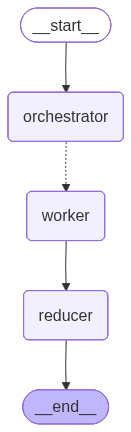

In [ ]:
workflow

In [ ]:
out = workflow.invoke({'topic':'write a blog on AI in healthcare'})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=Plan> {"audience": "healthcare professionals and developers", "tone": "practical", "blog_title": "Revolutionizing Healthcare with Artificial Intelligence", "tasks": [{"brief": "define AI in healthcare and its potential impact", "bullets": ["Explain the concept of AI in healthcare and its current applications", "Describe the potential benefits of AI in healthcare, including improved diagnostic accuracy and personalized medicine", "Discuss the potential risks and challenges of AI in healthcare, including bias and data quality issues"], "goal": "Understand the basics of AI in healthcare and its potential impact", "id": 1, "section_type": "intro", "target_words": 200, "title": "Introduction to AI in Healthcare"}, {"brief": "explain AI-powered dia

In [ ]:
out['final']

"# The Future of Healthcare: How AI is Revolutionizing the Industry \n\n **Introduction to AI in Healthcare**\n=====================================\n\nThe healthcare industry has come a long way in recent years, with the integration of Artificial Intelligence (AI) transforming the way medical professionals diagnose, treat, and care for patients. AI has been increasingly used in various aspects of healthcare, from data analysis and medical imaging to patient engagement and personalized medicine. In this blog, we will explore the current state of AI in healthcare and how it is revolutionizing the industry.\n\n**The Rise of AI in Healthcare**\n-------------------------------\n\nThe adoption of AI in healthcare is driven by the need to improve patient outcomes, reduce healthcare costs, and enhance the overall quality of care. AI algorithms can analyze vast amounts of medical data, identify patterns, and make predictions, allowing healthcare professionals to make more informed decisions. A